In [2]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import random
sns.set_style("whitegrid")

In [6]:
# --- 1. Setup and Configuration ---

# Define the list of valid activities to ensure we only load relevant files.
VALID_ACTIVITIES = ['sitting', 'walking', 'standing', 'sleeping', 'falling']


CSI_DATA_FOLDER = r"C:\Users\Ivan Nathanael\Personal\csi_data"
file_path_pattern = os.path.join(CSI_DATA_FOLDER, '*.csv')

In [9]:
# --- 2. Function to Load and Process All CSI Files ---

def load_all_csi_data(pattern: str, valid_activities: list) -> pd.DataFrame:
    """
    Loads all CSI data from a dedicated folder. It extracts the
    activity label and a session identifier from the specific filename format
    'esp32_csi_ACTIVITY_DATE_TIME.csv' and returns a single DataFrame.
    """
    all_files = glob.glob(pattern)
    df_list = []

    if not all_files:
        print(f"Warning: No CSV files found in the specified folder: '{CSI_DATA_FOLDER}'")
        print("Please make sure the folder exists and the path is correct.")
        return pd.DataFrame()

    print(f"Found {len(all_files)} CSV files in '{CSI_DATA_FOLDER}'. Processing...")

    for file_path in all_files:
        filename = os.path.basename(file_path)
        try:
            # Split the filename to extract the activity
            # e.g., 'esp32_csi_walking_20250728_152215.csv' -> ['esp32', 'csi', 'walking', ...]
            parts = filename.split('_')
            # The activity is the 3rd part (index 2)
            activity_label = parts[2]

            # Check if the extracted label is one of our valid activities
            if activity_label in valid_activities:
                temp_df = pd.read_csv(file_path)
                # Add the activity label as a new column
                temp_df['activity'] = activity_label
                # Add a unique session identifier from the filename
                temp_df['session'] = filename
                df_list.append(temp_df)
            else:
                print(f"Info: Skipping file with an invalid activity in its name: {filename}")

        except IndexError:
            print(f"Warning: Filename '{filename}' does not match the expected format 'esp32_csi_ACTIVITY_...'. Skipping.")
        except Exception as e:
            print(f"Could not read or process file: {filename}. Error: {e}")

    if not df_list:
        print("No valid data was loaded. Please check your file naming conventions.")
        return pd.DataFrame()

    # Concatenate all the individual DataFrames into a single master DataFrame
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

In [12]:
# --- 3. Execute Loading and Display Results ---

# Load the data using the function
master_df = load_all_csi_data(file_path_pattern, VALID_ACTIVITIES)

# Display the results only if data was successfully loaded
if not master_df.empty:
    print("\n--- Data Loading Complete ---")
    print(f"Shape of the combined DataFrame (rows, columns): {master_df.shape}")

    print("\n--- DataFrame Info ---")
    # Using 'verbose=False' for a cleaner summary if there are many columns
    master_df.info(verbose=False)

    print("\n--- Data Summary ---")
    print("Value counts for each activity:")
    print(master_df['activity'].value_counts())

    print("\n--- Head of the Final DataFrame ---")
    print(master_df.head())

    print("\n--- Tail of the Final DataFrame ---")
    print(master_df.tail())

Found 150 CSV files in 'C:\Users\Ivan Nathanael\Personal\csi_data'. Processing...

--- Data Loading Complete ---
Shape of the combined DataFrame (rows, columns): (12691452, 8)

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12691452 entries, 0 to 12691451
Columns: 8 entries, timestamp to session
dtypes: float64(3), int64(3), object(2)
memory usage: 774.6+ MB

--- Data Summary ---
Value counts for each activity:
activity
sitting     3110998
standing    2994121
sleeping    2331633
falling     2174177
walking     2080523
Name: count, dtype: int64

--- Head of the Final DataFrame ---
   timestamp  subcarrier_index   I   Q  magnitude  phase activity  \
0      0.002                 0  16  14     21.260  41.19  falling   
1      0.002                 1   0 -26     26.000 -90.00  falling   
2      0.002                 2  11 -24     26.401 -65.38  falling   
3      0.002                 3  11 -20     22.825 -61.19  falling   
4      0.002                 4   9 -17    


--- Visual Investigation of Zero-Value Anomaly ---

Analyzing random sample for 'falling' activity: esp32_csi_falling_20250727_131346.csv
  - Percentage of zeros in 'magnitude': 16.00%


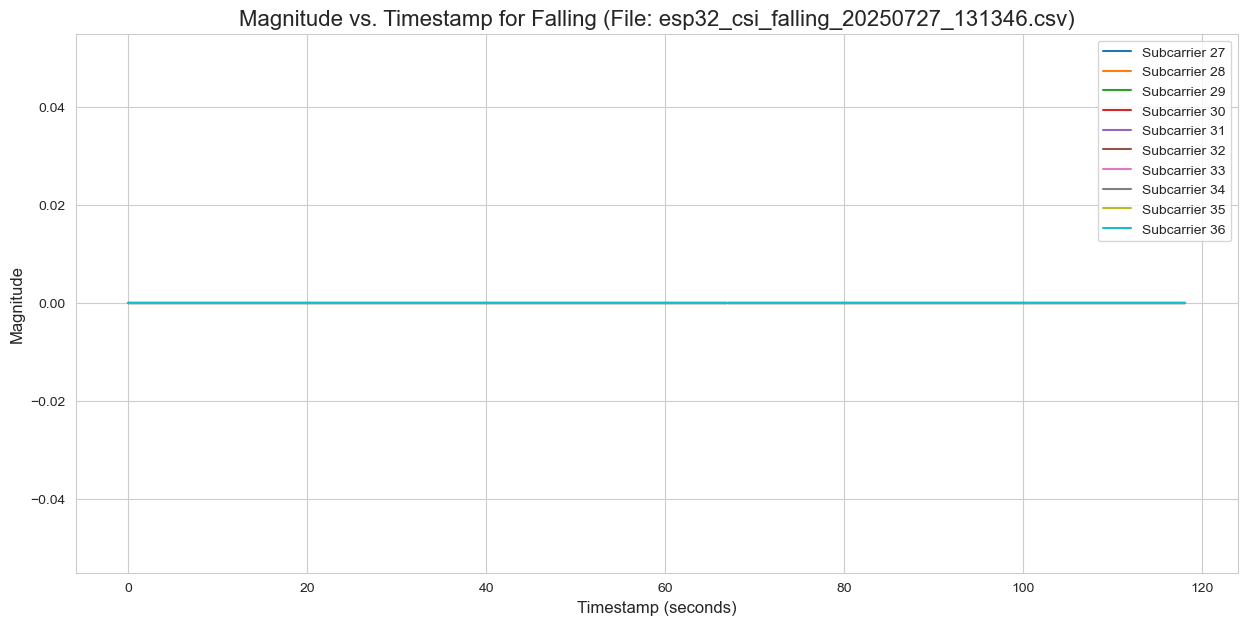


Analyzing random sample for 'sitting' activity: esp32_csi_sitting_20250728_130155.csv
  - Percentage of zeros in 'magnitude': 15.96%


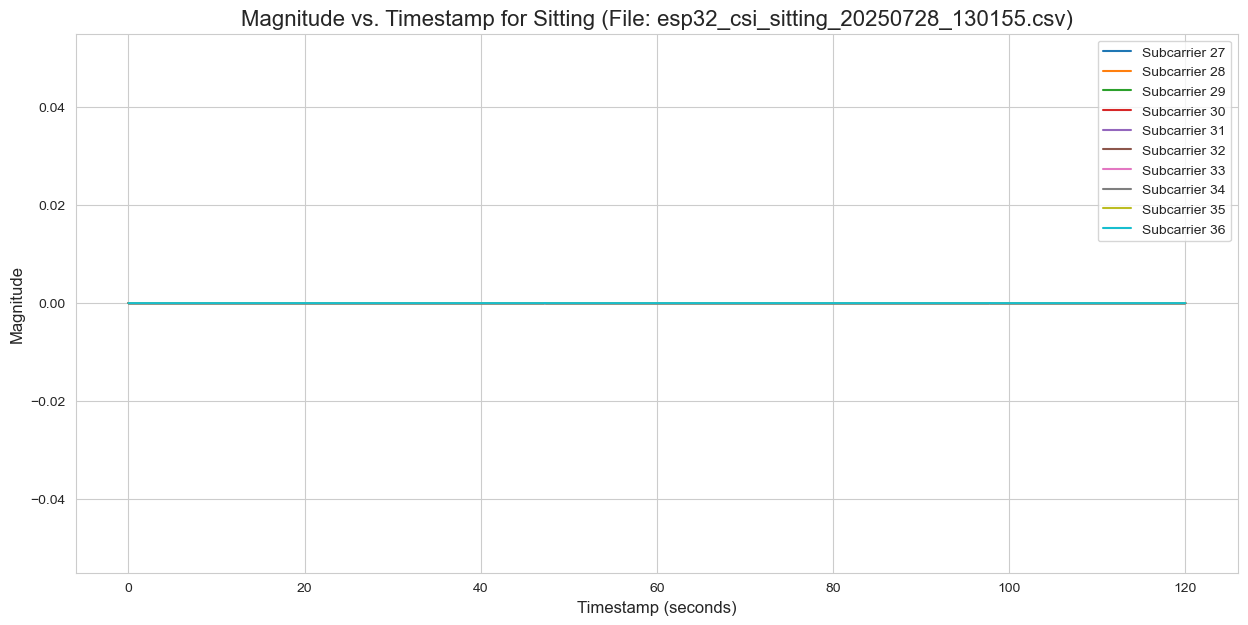


Analyzing random sample for 'sleeping' activity: esp32_csi_sleeping_20250727_162437.csv
  - Percentage of zeros in 'magnitude': 16.04%


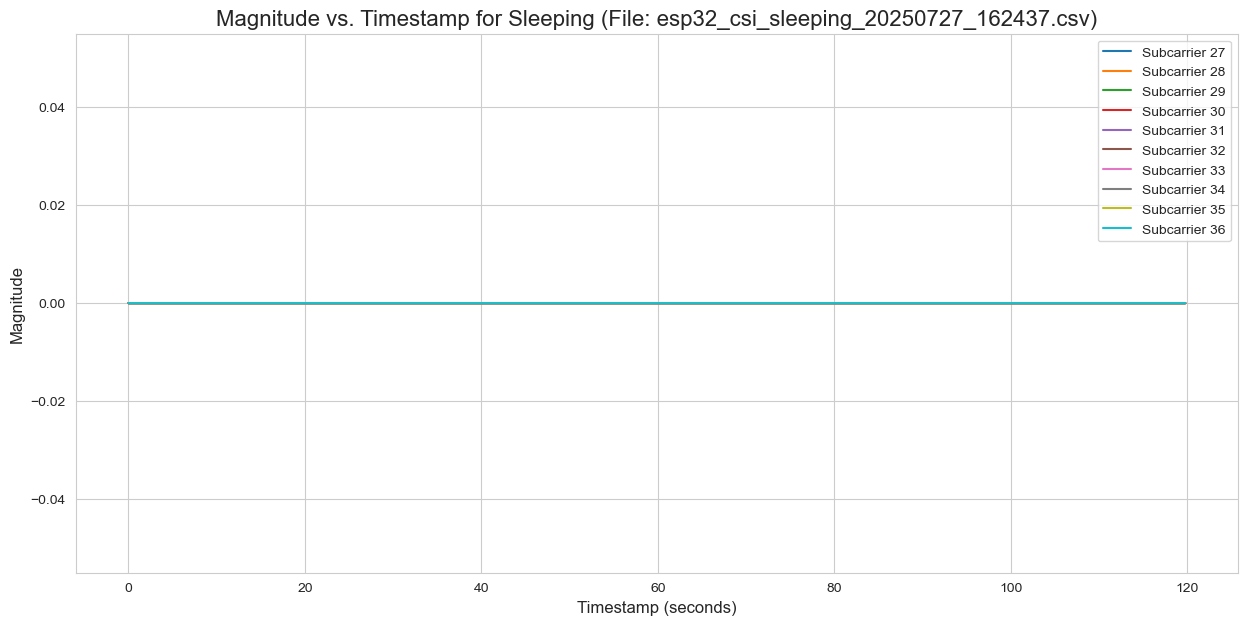


Analyzing random sample for 'standing' activity: esp32_csi_standing_20250728_141241.csv
  - Percentage of zeros in 'magnitude': 16.00%


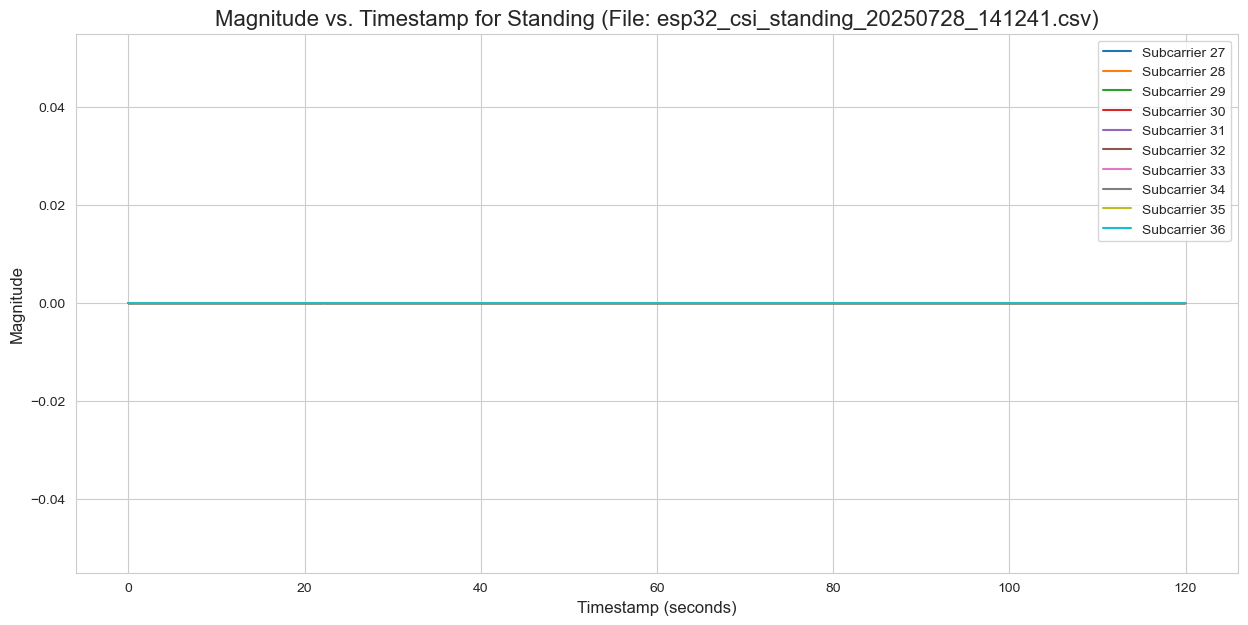


Analyzing random sample for 'walking' activity: esp32_csi_walking_20250728_150951.csv
  - Percentage of zeros in 'magnitude': 15.97%


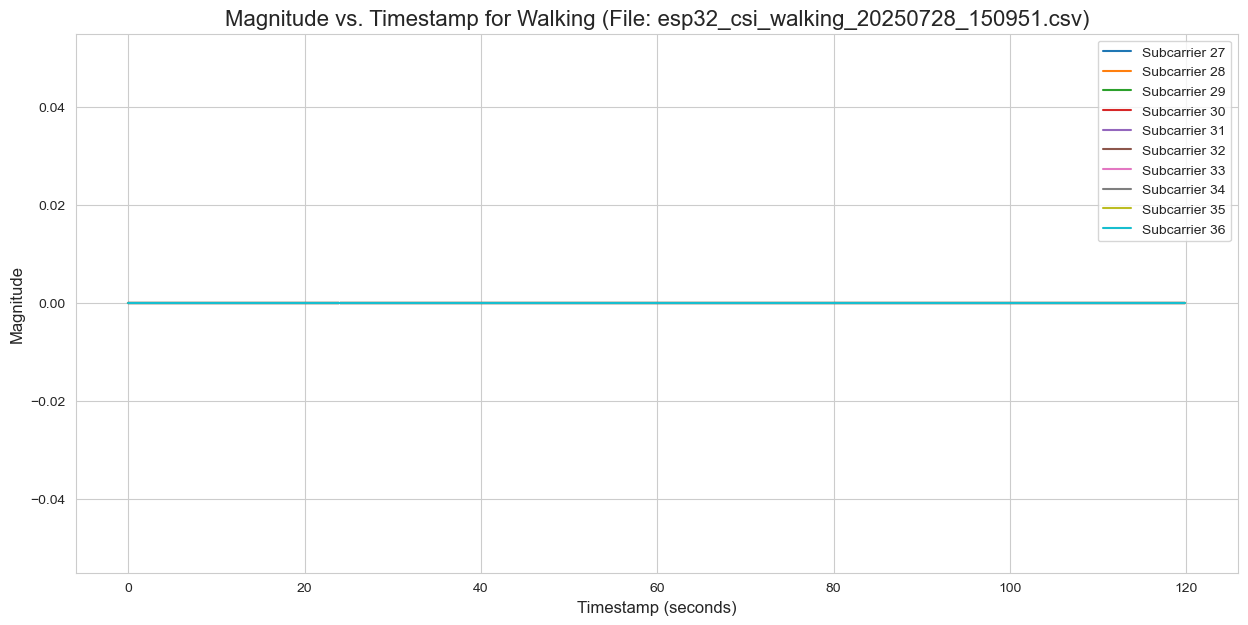

In [16]:
if not master_df.empty:
    print("\n--- Visual Investigation of Zero-Value Anomaly ---")
    
    
    # Get a list of all unique sessions (filenames)
    all_sessions = master_df['session'].unique()
    
    # Group sessions by activity
    grouped_sessions = master_df.groupby('activity')['session'].unique()

    # Loop through each activity to plot one random sample
    for activity, sessions in grouped_sessions.items():
        # Pick one random session from the list for this activity
        random_session_file = random.choice(sessions)
        print(f"\nAnalyzing random sample for '{activity}' activity: {random_session_file}")

        # Filter the master dataframe to get data for only the selected session
        session_df = master_df[master_df['session'] == random_session_file]

        # --- a. Quantify the zeros for this specific file ---
        zero_magnitude_percentage = (session_df['magnitude'] == 0).mean() * 100
        print(f"  - Percentage of zeros in 'magnitude': {zero_magnitude_percentage:.2f}%")

        # --- b. Visualize the pattern for this file ---
        # Pivot the data for easy plotting of subcarriers
        df_pivot = session_df.pivot(index='timestamp', columns='subcarrier_index', values='magnitude')
        
        # Select a few subcarriers to plot to keep the viz clean
        subcarriers_to_plot = [27, 28, 29, 30, 31, 32, 33, 34, 35, 36] #based on my inspection these are sub-carrier that most of the times have 0
        # Ensure the selected subcarriers exist in the data
        subcarriers_to_plot = [sc for sc in subcarriers_to_plot if sc in df_pivot.columns]

        # Create the plot
        plt.figure(figsize=(15, 7))
        for sc in subcarriers_to_plot:
            plt.plot(df_pivot.index, df_pivot[sc], label=f'Subcarrier {sc}')

        plt.title(f'Magnitude vs. Timestamp for {activity.capitalize()} (File: {random_session_file})', fontsize=16)
        plt.xlabel('Timestamp (seconds)', fontsize=12)
        plt.ylabel('Magnitude', fontsize=12)
        plt.legend()
        plt.show()

In [19]:
# Hypothesis Testing: Check for Null Subcarriers ---
if not master_df.empty:
    print("\n--- Hypothesis Test: Checking for Null Subcarriers (Indices 27-36) ---")
    
    # Define the subcarriers to investigate based on your hypothesis
    null_subcarriers_hypothesis = list(range(27, 37))
    
    # Filter the DataFrame to only include these subcarriers
    subcarrier_subset_df = master_df[master_df['subcarrier_index'].isin(null_subcarriers_hypothesis)]
    
    if not subcarrier_subset_df.empty:
        # Calculate the percentage of zero magnitude for each of these subcarriers
        # We group by the subcarrier index and then apply a function to each group
        zero_percentage_by_subcarrier = subcarrier_subset_df.groupby('subcarrier_index')['magnitude'].apply(lambda x: (x == 0).mean() * 100)
        
        print("Percentage of zero magnitude for each specified subcarrier:")
        # Using .to_string() ensures the full series is printed
        print(zero_percentage_by_subcarrier.to_string())
    else:
        print("Could not find data for the specified subcarriers (27-36).")


--- Hypothesis Test: Checking for Null Subcarriers (Indices 27-36) ---
Percentage of zero magnitude for each specified subcarrier:
subcarrier_index
27    100.000000
28    100.000000
29    100.000000
30    100.000000
31    100.000000
32     99.999007
33     99.999007
34     99.999007
35     99.998511
36     99.998511


In [22]:
# --- 6. Data Cleaning ---
if not master_df.empty:
    print("\n--- Data Cleaning ---")
    
    # Create a copy to work with, preserving the original master_df
    cleaned_df = master_df.copy()
    print(f"Initial shape of DataFrame: {cleaned_df.shape}")

    # --- Step 6.1: Remove Null Subcarriers ---
    null_subcarriers_to_remove = list(range(27, 37))
    print(f"\nRemoving null subcarriers (indices {null_subcarriers_to_remove})...")
    
    cleaned_df = cleaned_df[~cleaned_df['subcarrier_index'].isin(null_subcarriers_to_remove)]
    print(f"Shape after removing null subcarriers: {cleaned_df.shape}")

    # --- Step 6.2: Remove Periodic Dropout Windows ---
    print("\nIdentifying and removing periodic dropout windows...")
    
    # Group by both session and timestamp to uniquely identify each moment.
    magnitude_sum_by_session_time = cleaned_df.groupby(['session', 'timestamp'])['magnitude'].sum()
    
    # Get the (session, timestamp) pairs where the sum is 0
    dropout_indices = magnitude_sum_by_session_time[magnitude_sum_by_session_time == 0].index
    
    print(f"Found {len(dropout_indices)} (session, timestamp) pairs corresponding to dropout events.")
    
    # Set 'session' and 'timestamp' as index to efficiently drop the dropout windows
    cleaned_df = cleaned_df.set_index(['session', 'timestamp'])
    cleaned_df = cleaned_df.drop(index=dropout_indices)
    
    # Reset the index to bring 'session' and 'timestamp' back as columns
    cleaned_df = cleaned_df.reset_index()
    
    print(f"Final shape after removing dropout windows: {cleaned_df.shape}")
    
    print("\n--- Data Cleaning Complete ---")
    print("The 'cleaned_df' DataFrame is now ready for further processing.")


--- Data Cleaning ---
Initial shape of DataFrame: (12691452, 8)

Removing null subcarriers (indices [27, 28, 29, 30, 31, 32, 33, 34, 35, 36])...
Shape after removing null subcarriers: (10677148, 8)

Identifying and removing periodic dropout windows...
Found 0 (session, timestamp) pairs corresponding to dropout events.
Final shape after removing dropout windows: (10677148, 8)

--- Data Cleaning Complete ---
The 'cleaned_df' DataFrame is now ready for further processing.


In [24]:
# --- 7. Save the Cleaned Data ---
if 'cleaned_df' in locals() and not cleaned_df.empty:
    print("\n--- Saving Cleaned Data ---")
    
    # Save the file in the current working directory ---
    output_filename = "cleaned_csi_data.csv"
    
    # Save the DataFrame to a CSV file in the same directory as the notebook
    # index=False prevents pandas from writing the DataFrame index as a column
    cleaned_df.to_csv(output_filename, index=False)
    
    print(f"Cleaned data successfully saved to: {os.path.abspath(output_filename)}")


--- Saving Cleaned Data ---
Cleaned data successfully saved to: C:\Users\Ivan Nathanael\Uni\Side Project\csi_Ivan\cleaned_csi_data.csv
